# Bank Customer Churn Machine Learning Model

In [ ]:
# import library
import numpy as np 
import pandas as pd
# visualization
import matplotlib.pyplot as plt 
import seaborn as sns 
#
import warnings
warnings.filterwarnings('ignore')
# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# Interpretability
from sklearn.inspection import permutation_importance
import lime
import lime.lime_tabular

In [125]:
pd.set_option('display.max_colwidth', 50)

In [126]:
# Importing the dataset
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')

In [127]:
df_train

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165029,165029,15667085,Meng,667,Spain,Female,33.0,2,0.00,1,1.0,1.0,131834.75,0
165030,165030,15665521,Okechukwu,792,France,Male,35.0,3,0.00,1,0.0,0.0,131834.45,0
165031,165031,15664752,Hsia,565,France,Male,31.0,5,0.00,1,1.0,1.0,127429.56,0
165032,165032,15689614,Hsiung,554,Spain,Female,30.0,7,161533.00,1,0.0,1.0,71173.03,0


In [128]:
df_test

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110018,275052,15662091,P'eng,570,Spain,Male,29.0,7,116099.82,1,1.0,1.0,148087.62
110019,275053,15774133,Cox,575,France,Female,36.0,4,178032.53,1,1.0,1.0,42181.68
110020,275054,15728456,Ch'iu,712,France,Male,31.0,2,0.00,2,1.0,0.0,16287.38
110021,275055,15687541,Yegorova,709,France,Female,32.0,3,0.00,1,1.0,1.0,158816.58


## EDA

In [129]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB


In [130]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [131]:
print(f"train shape: {df_train.shape}")
print(f"test shape: {df_test.shape}")

train shape: (165034, 14)
test shape: (110023, 13)


In [132]:
# Data type
df_train.dtypes


id                   int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object

In [133]:
df_test.dtypes

id                   int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
dtype: object

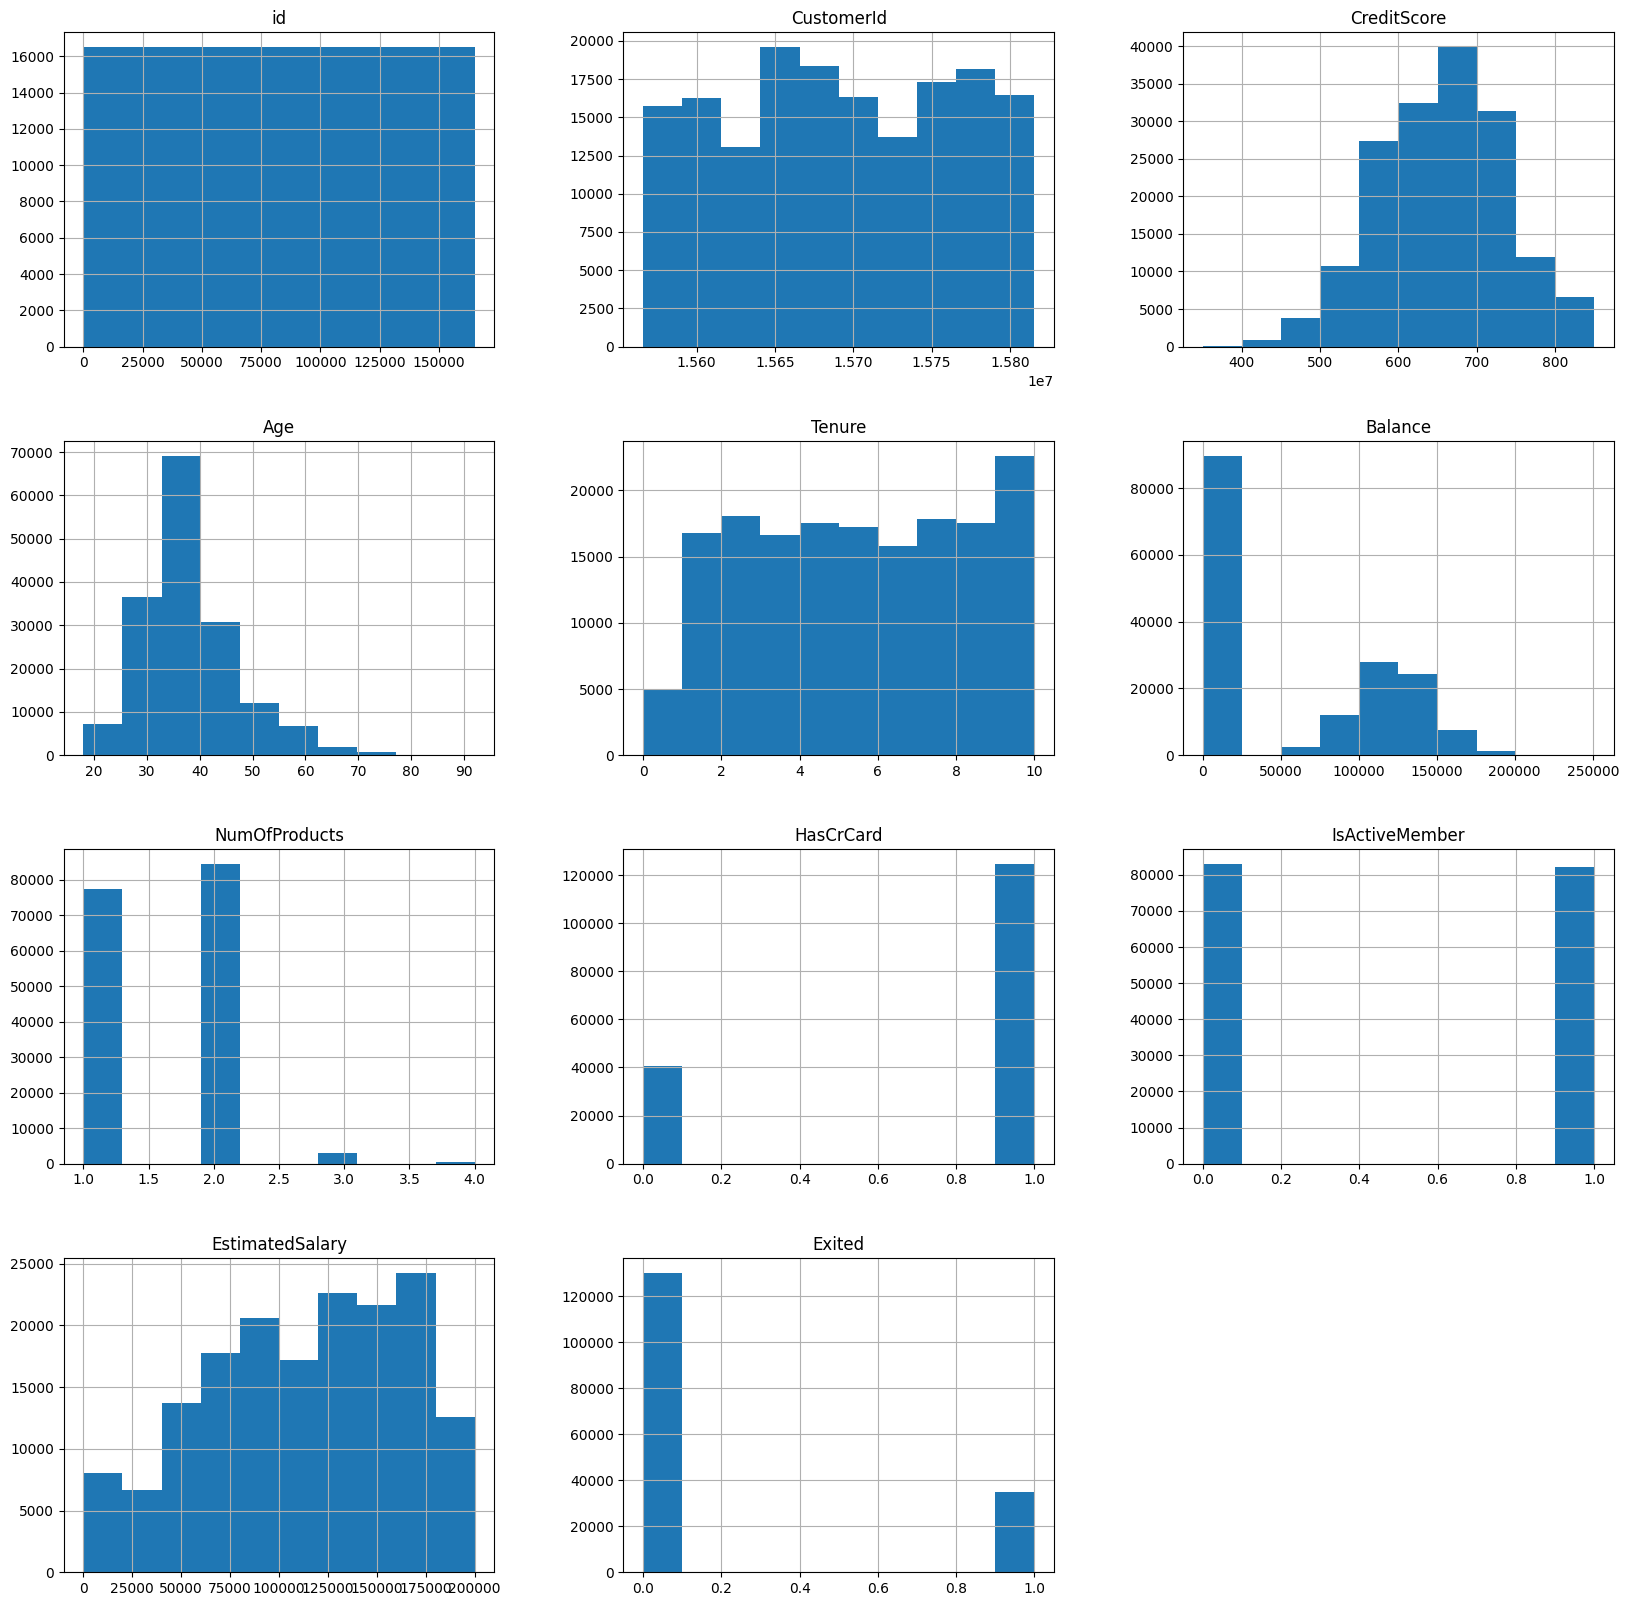

In [134]:
#plot histogram of all numeric features
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
df_train[numeric_features].hist(figsize=(20, 20))
plt.show()

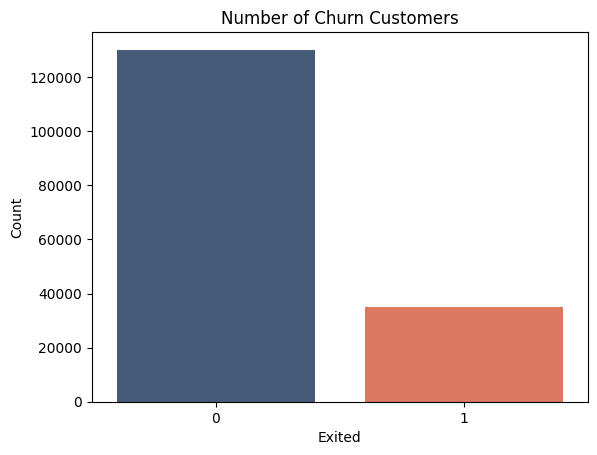

Exited
0    78.840118
1    21.159882
Name: proportion, dtype: float64


In [135]:
#make the bar chart show number of churn customer with color 3d5a80 ee6c4d
sns.countplot(x='Exited', data=df_train, palette=['#3d5a80', '#ee6c4d'])
plt.title('Number of Churn Customers')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()
# show the percentage of churn customers
churn_percentage = df_train['Exited'].value_counts(normalize=True) * 100
print(churn_percentage)

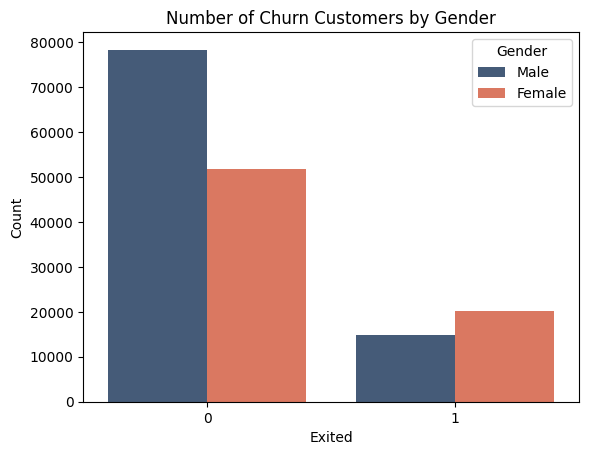

In [136]:
# plot the churn customer by gender
sns.countplot(x='Exited', hue='Gender', data=df_train, palette=['#3d5a80', '#ee6c4d'])
plt.title('Number of Churn Customers by Gender')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

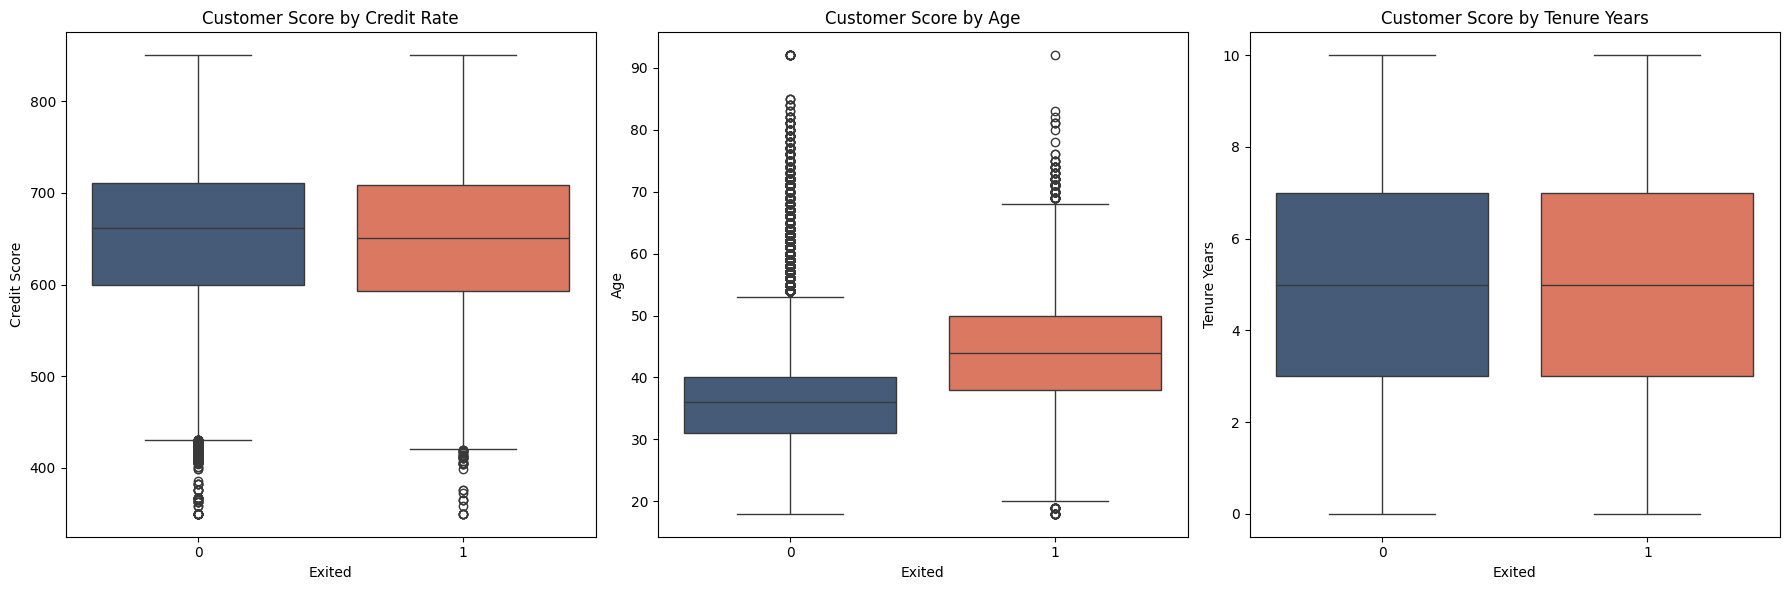

In [137]:
# Set up a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Credit Score
sns.boxplot(x='Exited', y='CreditScore', data=df_train, palette=['#3d5a80', '#ee6c4d'], ax=axes[0])
axes[0].set_title('Customer Score by Credit Rate')
axes[0].set_xlabel('Exited')
axes[0].set_ylabel('Credit Score')

# Plot 2: Age
sns.boxplot(x='Exited', y='Age', data=df_train, palette=['#3d5a80', '#ee6c4d'], ax=axes[1])
axes[1].set_title('Customer Score by Age')
axes[1].set_xlabel('Exited')
axes[1].set_ylabel('Age')

# Plot 3: Tenure
sns.boxplot(x='Exited', y='Tenure', data=df_train, palette=['#3d5a80', '#ee6c4d'], ax=axes[2])
axes[2].set_title('Customer Score by Tenure Years')
axes[2].set_xlabel('Exited')
axes[2].set_ylabel('Tenure Years')

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

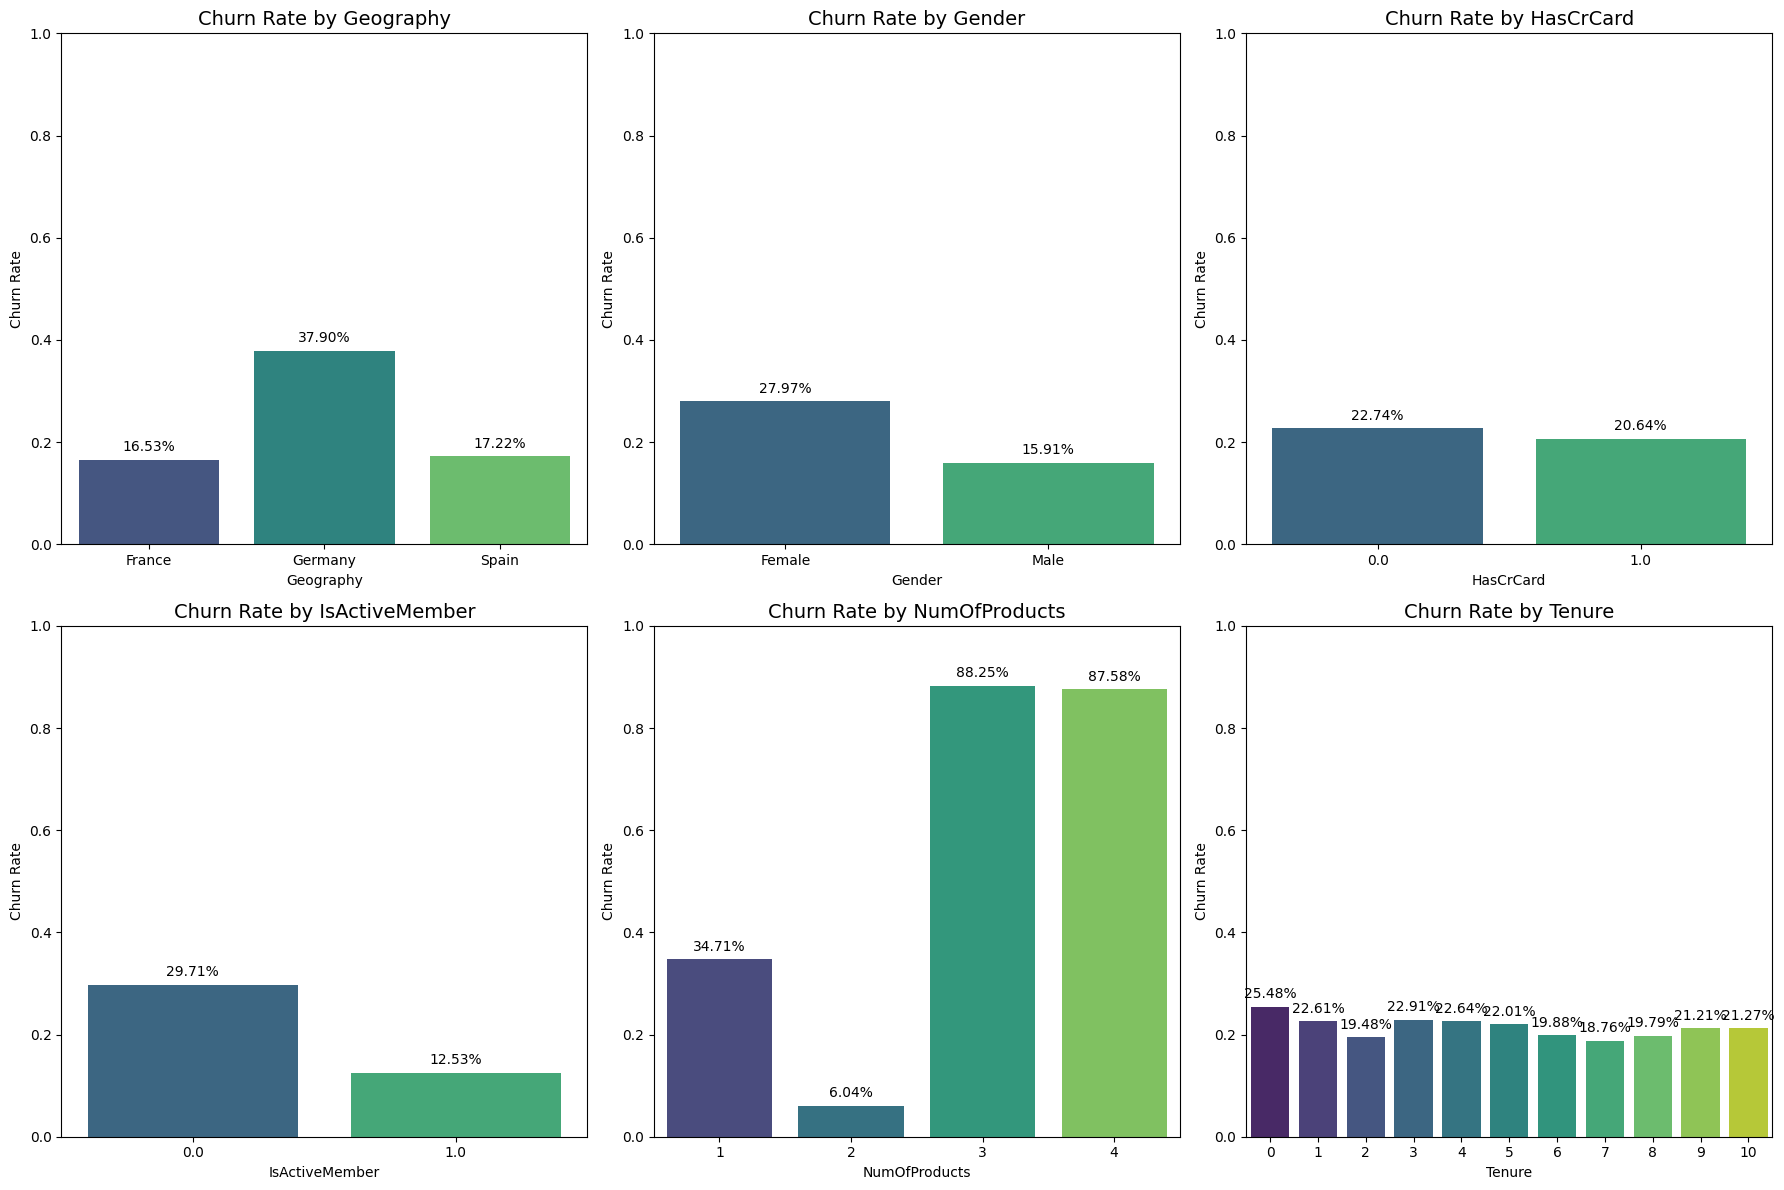

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical or discrete columns to analyze
# We exclude 'Exited' (the target) and 'CustomerId'/'Surname' (identifiers)
cols_to_plot = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure']

# Set up the figure grid (e.g., 2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to iterate easily

for i, col in enumerate(cols_to_plot):
    # Calculate churn rate for each category
    churn_rate = df_train.groupby(col)['Exited'].mean().reset_index()
    
    # Create the bar plot
    sns.barplot(x=col, y='Exited', data=churn_rate, ax=axes[i], palette='viridis')
    
    # Customizing each subplot
    axes[i].set_title(f'Churn Rate by {col}', fontsize=14)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel(col)
    axes[i].set_ylim(0, 1) # Probability is between 0 and 1
    
    # Add percentage labels on top of bars
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 9), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()

In [139]:
import pandas as pd
from scipy.stats import chi2_contingency

# Initialize a list to store results
chi2_results = []

categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure']

for feature in categorical_features:
    # Create contingency table
    contingency_table = pd.crosstab(df_train[feature], df_train['Exited'])
    
    # Perform test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Append results to list
    chi2_results.append({
        'Feature': feature,
        'Chi2 Statistic': f"{chi2:.4f}",
        'p-value': f"{p:.4f}",
        'Result': 'Significant' if p < 0.05 else 'Not Significant'
    })

# Convert to DataFrame for a tabular view
chi2_table = pd.DataFrame(chi2_results)

# Display the table
print(chi2_table)

          Feature Chi2 Statistic p-value       Result
0       Geography      7358.6738  0.0000  Significant
1          Gender      3538.4525  0.0000  Significant
2       HasCrCard        80.7802  0.0000  Significant
3  IsActiveMember      7293.4085  0.0000  Significant
4   NumOfProducts     29130.4790  0.0000  Significant
5          Tenure       265.4585  0.0000  Significant


This is the strongest predictor. The relationship between how many products a customer has and whether they leave is incredibly strong.

The F-Statistic measures how much the means of the groups vary relative to the variation within the groups. The higher the F-Statistic, the more "separating power" that feature has.

In [140]:
# do anova test for numeric features
from scipy.stats import f_oneway
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
anova_results = []
for feature in numeric_features:
    group0 = df_train[df_train['Exited'] == 0][feature]
    group1 = df_train[df_train['Exited'] == 1][feature]
    
    f_stat, p_value = f_oneway(group0, group1)
    
    anova_results.append({
        'Feature': feature,
        'F-Statistic': f"{f_stat:.4f}",
        'p-value': f"{p_value:.4f}",
        'Result': 'Significant' if p_value < 0.05 else 'Not Significant'
    })
anova_table = pd.DataFrame(anova_results)
print(anova_table)

           Feature F-Statistic p-value       Result
0      CreditScore    123.8350  0.0000  Significant
1              Age  21681.7498  0.0000  Significant
2           Tenure     63.1957  0.0000  Significant
3          Balance   2825.5819  0.0000  Significant
4    NumOfProducts   7963.5959  0.0000  Significant
5  EstimatedSalary     58.5161  0.0000  Significant


age is by far the most important numeric feature

# Data Preprocessing

In [141]:
# Prepare data for modeling
X=df_train.drop(['Exited', 'CustomerId',"id"], axis=1)
y=df_train['Exited']

In [142]:
#split data into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [143]:
#shape of train and test set
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (132027, 11)
X_test shape: (33007, 11)
y_train shape: (132027,)
y_test shape: (33007,)


In [144]:
ohe= OneHotEncoder(sparse_output =False, drop='first') # encode the categorical features
standard_scaler = StandardScaler() # normalize the numeric features

In [145]:
#make a pipeline to preprocess the data
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', standard_scaler, ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']),
        ('cat', ohe, ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember','NumOfProducts'])
    ])


# Build Model

## Logistic Regression

In [146]:

# Build a pipeline with preprocessor and logistic regression model
#1.Logistic- We use logistic regression as a baseline model for binary classification
lr= LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
# 2. Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lr)
])
# 3.Hyperparameter
# 4. Cross-validation
# 5. Hyperparameter tuning
# 6. Fit model (final model)
lr_model = lr_pipeline.fit(X_train, y_train)
# 7. Best parameters
# 8. Final model


In [147]:
# Predict on validation set
# Predict class labels
y_pred_lr = lr_model.predict(X_test)
# Predict probabilities (for ROC-AUC)
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1] # probability for class 1
y_train_proba_lr = lr_model.predict_proba(X_train)[:, 1]

Logistic Regression Accuracy: 0.7939
Logistic Regression ROC-AUC: 0.8701


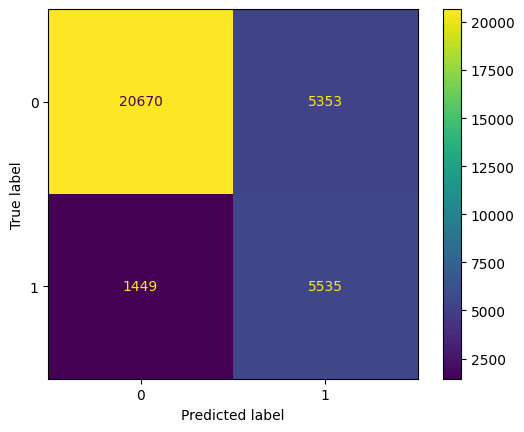

In [148]:
# accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
#print auc score and confusion matrix
roc_auc = roc_auc_score(y_test, y_test_proba_lr)
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix= conf_matrix, display_labels=[0, 1])
disp.plot(values_format='d') # 'd' for integer counts
plt.show()


In [149]:
# print auc score and classification report
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression ROC-AUC: 0.8701
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     26023
           1       0.51      0.79      0.62      6984

    accuracy                           0.79     33007
   macro avg       0.72      0.79      0.74     33007
weighted avg       0.84      0.79      0.81     33007



In [150]:
# Build a pipeline with preprocessor and logistic regression model
#1.Logistic- We use logistic regression as a baseline model for binary classification
lr= LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
# 2. Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lr)
])
# 3.Hyperparameter
# 4. Cross-validation
# 5. Hyperparameter tuning
# 6. Fit model (final model)
lr_model = lr_pipeline.fit(X_train, y_train)
# 7. Best parameters
# 8. Final model


In [151]:
#Logistic regression with hyperparameter tuning
# 1. Update Model: Use 'liblinear' or 'saga' solver as they support both L1 and L2
lr = LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced', solver='liblinear')

# 2. Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lr)
])

# 3. Hyperparameter Space
# 'penalty': 'l1' is Lasso, 'l2' is Ridge
# 'C': Smaller values mean STRONGER regularization
param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# 4 & 5. Cross-validation and Tuning
# We use 5-fold CV and optimize for ROC-AUC
grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# 
# 6. Fit final model
grid_search.fit(X_train, y_train)

# 7. Best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# 8. Final model
lr_model_withreg = grid_search.best_estimator_

Best Parameters: {'model__C': 10, 'model__penalty': 'l1'}
Best CV ROC-AUC: 0.8710


The logistic regression with regularization performs a little bit better than the classic logistic regression

Ridge is used when we want to keep all features but reduce their impact, while Lasso can set some coefficients to zero, effectively performing feature selection.

In [154]:
# Feature importance for logistic regression
# Get feature names after preprocessing
feature_names_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
feature_names_cat = grid_search.best_estimator_.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(['Geography', 'Gender', 'HasCrCard', 'IsActiveMember','NumOfProducts'])
feature_names = feature_names_num + list(feature_names_cat)
# Get coefficients from the logistic regression model
coefficients = lr_model_withreg.named_steps['model'].coef_[0]
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute Coefficient', ascending=False)
print(feature_importance[['Feature', 'Coefficient']])


               Feature  Coefficient
11     NumOfProducts_3     2.590576
12     NumOfProducts_4     2.311551
10     NumOfProducts_2    -2.083799
5    Geography_Germany     1.235521
9   IsActiveMember_1.0    -1.189778
1                  Age     0.810215
7          Gender_Male    -0.672010
3              Balance    -0.252475
8        HasCrCard_1.0    -0.212289
0          CreditScore    -0.060524
2               Tenure    -0.048239
4      EstimatedSalary     0.034068
6      Geography_Spain     0.013984


# Random Forest

In [157]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. Update Model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf)
])

# 3. Hyperparameter Space using randint
# randint(low, high) picks a random integer between those two numbers
param_dist_rf = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [None, 10, 20, 30, 40, 50],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2']
}

# 4 & 5. Randomized Search
# n_iter=20 means it will try 20 random combinations
random_search_rf = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=param_dist_rf, 
    n_iter=20, 
    cv=5, 
    scoring='roc_auc', 
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 6. Fit final model
random_search_rf.fit(X_train, y_train)

# 7. Best parameters
print(f"Best Parameters: {random_search_rf.best_params_}")
print(f"Best CV ROC-AUC: {random_search_rf.best_score_:.4f}")

# 8. Final model
rf_model = random_search_rf.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 15, 'model__n_estimators': 450}
Best CV ROC-AUC: 0.8865


Best Parameters: {'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 15, 'model__n_estimators': 450}
Best CV ROC-AUC: 0.8865

In [158]:
# predict on validation set
y_pred_lr = lr_model.predict(X_test)
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1]


Logistic Regression ROC-AUC: 0.8701


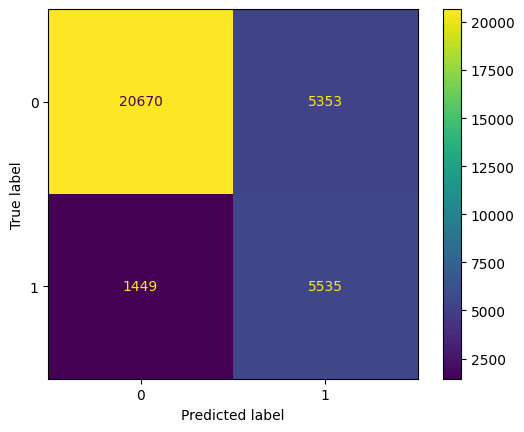

In [160]:
# roc auc score
roc_auc = roc_auc_score(y_test, y_test_proba_lr)
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")

# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1])
disp.plot(values_format='d') # 'd' for integer counts
plt.show()

In [161]:
# the importance of features in random forest
feature_importance_rf = rf_model.named_steps['model'].feature_importances_
feature_importance_df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance_rf
}).sort_values(by='Importance', ascending=False)
print(feature_importance_df_rf)


               Feature  Importance
10     NumOfProducts_2    0.370731
1                  Age    0.298988
9   IsActiveMember_1.0    0.096051
5    Geography_Germany    0.062852
3              Balance    0.057661
7          Gender_Male    0.035506
11     NumOfProducts_3    0.034938
4      EstimatedSalary    0.013899
0          CreditScore    0.013653
2               Tenure    0.006661
12     NumOfProducts_4    0.003515
8        HasCrCard_1.0    0.002860
6      Geography_Spain    0.002685


In [ ]:
# Using LIME for interpretability of the random forest model

# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=preprocessor.fit_transform(X_train),
    feature_names=feature_names,        
    class_names=['Not Churn', 'Churn'],
    mode='classification'
)
# Explain a single prediction (e.g., the first instance in the test set)
i = 0
exp = explainer.explain_instance(
    data_row=preprocessor.transform(X_test)[i],
    predict_fn=rf_model.named_steps['model'].predict_proba
)
# Show the explanation
exp.show_in_notebook(show_table=True)


Lime is the local interpretor.

In [164]:
# USE PERMUTATION IMPORTANCE FOR RANDOM FOREST
from sklearn.inspection import permutation_importance
# Get the preprocessed test data
X_test_preprocessed = preprocessor.transform(X_test)
# Calculate permutation importance
perm_importance = permutation_importance(
    rf_model.named_steps['model'],
    X_test_preprocessed,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
# Create a DataFrame for permutation importance
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)
print(perm_importance_df)


               Feature  Importance Mean  Importance Std
10     NumOfProducts_2         0.100103        0.001797
1                  Age         0.063096        0.001599
9   IsActiveMember_1.0         0.023640        0.000970
3              Balance         0.018408        0.000816
7          Gender_Male         0.006929        0.000846
11     NumOfProducts_3         0.004820        0.000268
5    Geography_Germany         0.002990        0.000918
0          CreditScore         0.001079        0.000544
4      EstimatedSalary         0.000682        0.000402
12     NumOfProducts_4         0.000570        0.000074
8        HasCrCard_1.0         0.000400        0.000301
2               Tenure         0.000354        0.000347
6      Geography_Spain        -0.001315        0.000348


This is one of the most reliable ways to understand Global Explainability because it measures how much the model actually relies on a feature to make accurate predictions.

Shuffling the column numofproduct_2 causes a massive 10% drop in performance. This confirms that whether a customer has exactly 2 products is the single biggest "clue" the model uses to decide if they will stay or leave.

Age (0.0630): Age remains a critical global driver. The model relies heavily on the patterns it found in the age demographic to distinguish churners.

Text(0.5, 1.0, 'ROC Curve Comparison')

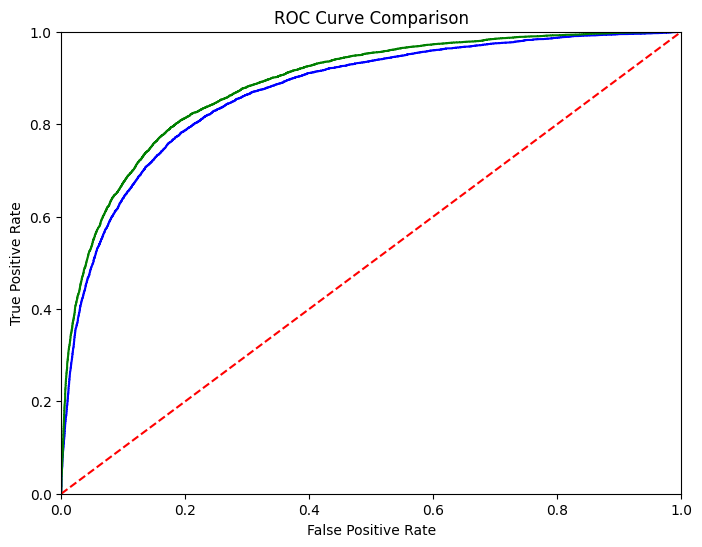

In [168]:
# draw roc curve of three models lr, rf 
from sklearn.metrics import roc_curve, auc
# Get predicted probabilities for each model
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]
# Calculate ROC curve and AUC for logistic regression 
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
# Calculate ROC curve and AUC for random forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', color='green')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve Comparison')       

Random Forest outperforms Logistic Regression